In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
# Load cleaned datasets

customers = pd.read_csv('../data/processed/customers_clean.csv')
restaurants = pd.read_csv('../data/processed/restaurants_clean.csv')
orders = pd.read_csv('../data/processed/orders_clean.csv')
deliveries = pd.read_csv('../data/processed/deliveries_clean.csv')
drivers = pd.read_csv('../data/processed/drivers_clean.csv')
reviews = pd.read_csv('../data/processed/reviews_clean.csv')
payments = pd.read_csv('../data/processed/payments_clean.csv')

In [3]:
# Convert date columns to datetime

customers['signup_date'] = pd.to_datetime(
    customers['signup_date']
)

orders['order_timestamp'] = pd.to_datetime(
    orders['order_timestamp']
)

In [4]:
# Create time-based features from order timestamps

orders['order_day_of_week'] = (
    orders['order_timestamp'].dt.dayofweek
)

orders['order_hour'] = (
    orders['order_timestamp'].dt.hour
)

In [5]:
# Identify weekend orders

orders['is_weekend'] = (
    orders['order_day_of_week'] >= 5
).astype(int)

In [6]:
# Identify late-night orders

orders['is_late_night'] = (
    (orders['order_hour'] >= 22)
    | (orders['order_hour'] < 6)
).astype(int)

In [8]:
# Calculate basic customer-level order metrics

customer_order_features = (
    orders
    .groupby('customer_id')
    .agg(
        total_orders=('order_id', 'count'),
        average_order_value=('order_amount', 'mean'),
        total_spending=('order_amount', 'sum'),
        weekend_orders=('is_weekend', 'sum'),
        late_night_orders=('is_late_night', 'sum')
    )
    .reset_index()
)

# Display customer order features

customer_order_features.head()

,customer_id,total_orders,average_order_value,total_spending,weekend_orders,late_night_orders
0,CUST_00001,7,705.661429,4939.63,1,2
1,CUST_00002,10,959.321000,9593.21,4,1
2,CUST_00003,5,649.778000,3248.89,1,0
3,CUST_00004,5,671.152000,3355.76,2,1
4,CUST_00005,7,693.558571,4854.91,1,1


In [12]:
# Calculate the number of active months for each customer

customer_active_months = (
    orders
    .assign(
        order_month=orders['order_timestamp'].dt.to_period('M')
    )
    .groupby('customer_id')['order_month']
    .nunique()
    .reset_index(
        name='active_months'
    )
)

# Calculate average orders per active month

customer_order_features = customer_order_features.merge(
    customer_active_months,
    on='customer_id',
    how='left'
)

customer_order_features['ordering_frequency'] = (
    customer_order_features['total_orders']/ customer_order_features['active_months']
)

# Remove intermediate feature

customer_order_features = customer_order_features.drop(
    columns='active_months'
)

In [14]:
# Calculate average rating given by each customer

customer_rating_features = (
    reviews
    .groupby('customer_id')
    .agg(
        average_rating_given=(
            'review_rating',
            'mean'
        )
    )
    .reset_index()
)

# Add customer rating information

customer_features = customer_order_features.merge(
    customer_rating_features,
    on='customer_id',
    how='left'
)

In [15]:
# Inspect the customer feature dataset

customer_features.head()

,customer_id,total_orders,average_order_value,total_spending,weekend_orders,late_night_orders,active_months_x,ordering_frequency,active_months_y,average_rating_given
0,CUST_00001,7,705.661429,4939.63,1,2,5,1.4,5,4.000000
1,CUST_00002,10,959.321000,9593.21,4,1,5,2.0,5,3.800000
2,CUST_00003,5,649.778000,3248.89,1,0,5,1.0,5,4.333333
3,CUST_00004,5,671.152000,3355.76,2,1,5,1.0,5,3.750000
4,CUST_00005,7,693.558571,4854.91,1,1,5,1.4,5,3.333333


In [16]:
# Check customer feature information

customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 1497 entries, 0 to 1496
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           1497 non-null   str    
 1   total_orders          1497 non-null   int64  
 2   average_order_value   1497 non-null   float64
 3   total_spending        1497 non-null   float64
 4   weekend_orders        1497 non-null   int64  
 5   late_night_orders     1497 non-null   int64  
 6   active_months_x       1497 non-null   int64  
 7   ordering_frequency    1497 non-null   float64
 8   active_months_y       1497 non-null   int64  
 9   average_rating_given  1489 non-null   float64
dtypes: float64(4), int64(5), str(1)
memory usage: 117.1 KB


In [17]:
# Check missing values in engineered features

customer_features.isna().sum()

customer_id             0
total_orders            0
average_order_value     0
total_spending          0
weekend_orders          0
late_night_orders       0
active_months_x         0
ordering_frequency      0
active_months_y         0
average_rating_given    8
dtype: int64

In [ ]:
# Fill missing customer ratings with the overall average rating

customer_features['average_rating_given'] = (
    customer_features['average_rating_given']
    .fillna(
        customer_features['average_rating_given'].mean()
    )
)

# Why mean imputation here?

# Only 8 customers are affected.
# The missingness represents no review, rather than corrupted data.
# We need a complete numerical matrix for StandardScaler and clustering.
# Dropping those customers would unnecessarily remove valid customer behavior from our segmentation.

In [19]:
# Display final customer features

customer_features = customer_features[
    [
        'customer_id',
        'total_orders',
        'average_order_value',
        'total_spending',
        'ordering_frequency',
        'average_rating_given',
        'weekend_orders',
        'late_night_orders'
    ]
]

customer_features.head()

,customer_id,total_orders,average_order_value,total_spending,ordering_frequency,average_rating_given,weekend_orders,late_night_orders
0,CUST_00001,7,705.661429,4939.63,1.4,4.000000,1,2
1,CUST_00002,10,959.321000,9593.21,2.0,3.800000,4,1
2,CUST_00003,5,649.778000,3248.89,1.0,4.333333,1,0
3,CUST_00004,5,671.152000,3355.76,1.0,3.750000,2,1
4,CUST_00005,7,693.558571,4854.91,1.4,3.333333,1,1


In [20]:
customer_features.isna().sum()

customer_id             0
total_orders            0
average_order_value     0
total_spending          0
ordering_frequency      0
average_rating_given    8
weekend_orders          0
late_night_orders       0
dtype: int64

In [22]:
# Display summary statistics for customer features

customer_features.describe()

,total_orders,average_order_value,total_spending,ordering_frequency,average_rating_given,weekend_orders,late_night_orders
count,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000
mean,6.680027,741.737341,4976.819192,1.754643,4.051247,1.918504,0.867735
std,2.744676,372.486407,3128.970086,0.567050,0.356967,1.410915,0.943530
min,1.000000,134.910000,162.440000,1.000000,2.000000,0.000000,0.000000
25%,5.000000,486.489091,2696.430000,1.333333,3.833333,1.000000,0.000000
50%,6.000000,661.305000,4341.760000,1.666667,4.000000,2.000000,1.000000
75%,8.000000,913.040000,6555.770000,2.000000,4.250000,3.000000,1.000000
max,17.000000,3398.813333,23775.690000,6.000000,5.000000,8.000000,7.000000


In [24]:
# Remove customer identifier before model training

customer_model_data = customer_features.drop(
    columns='customer_id'
)

# Display the features that will be used for clustering

customer_model_data.head()

,total_orders,average_order_value,total_spending,ordering_frequency,average_rating_given,weekend_orders,late_night_orders
0,7,705.661429,4939.63,1.4,4.000000,1,2
1,10,959.321000,9593.21,2.0,3.800000,4,1
2,5,649.778000,3248.89,1.0,4.333333,1,0
3,5,671.152000,3355.76,1.0,3.750000,2,1
4,7,693.558571,4854.91,1.4,3.333333,1,1


In [26]:
# Standardize customer features

scaler = StandardScaler()

customer_scaled = scaler.fit_transform(
    customer_model_data
)

# Create a DataFrame containing the scaled features

customer_scaled_df = pd.DataFrame(
    customer_scaled,
    columns=customer_model_data.columns
)

customer_scaled_df.head()

,total_orders,average_order_value,total_spending,ordering_frequency,average_rating_given,weekend_orders,late_night_orders
0,0.116619,-0.096884,-0.011889,-0.625626,-0.143611,-0.651216,1.200432
1,1.210009,0.584334,1.475864,0.432835,-0.704074,1.475775,0.140227
2,-0.612308,-0.246962,-0.552420,-1.331267,0.790494,-0.651216,-0.919977
3,-0.612308,-0.189561,-0.518254,-1.331267,-0.844190,0.057781,0.140227
4,0.116619,-0.129387,-0.038974,-0.625626,-2.011822,-0.651216,0.140227


In [27]:
# Verify that the features have been standardized

customer_scaled_df.describe().round(2)

,total_orders,average_order_value,total_spending,ordering_frequency,average_rating_given,weekend_orders,late_night_orders
count,1497.00,1497.00,1497.00,1497.00,1497.00,1497.00,1497.00
mean,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.07,-1.63,-1.54,-1.33,-5.75,-1.36,-0.92
25%,-0.61,-0.69,-0.73,-0.74,-0.61,-0.65,-0.92
50%,-0.25,-0.22,-0.20,-0.16,-0.14,0.06,0.14
75%,0.48,0.46,0.50,0.43,0.56,0.77,0.14
max,3.76,7.14,6.01,7.49,2.66,4.31,6.50


In [28]:
# Calculate K-Means inertia for different numbers of clusters

inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(customer_scaled)
    
    inertia_values.append(kmeans.inertia_)

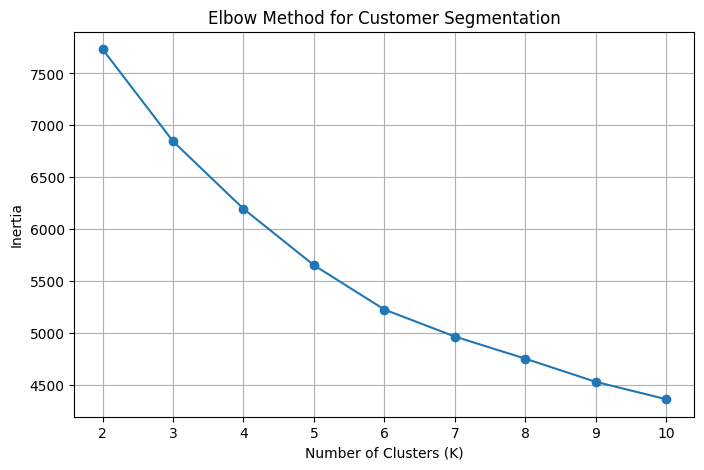

In [29]:
# Plot the Elbow Method

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_values,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Customer Segmentation')

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [30]:
# Calculate silhouette scores for different numbers of clusters

silhouette_values = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(
        customer_scaled
    )
    
    score = silhouette_score(
        customer_scaled,
        cluster_labels
    )
    
    silhouette_values.append(score)

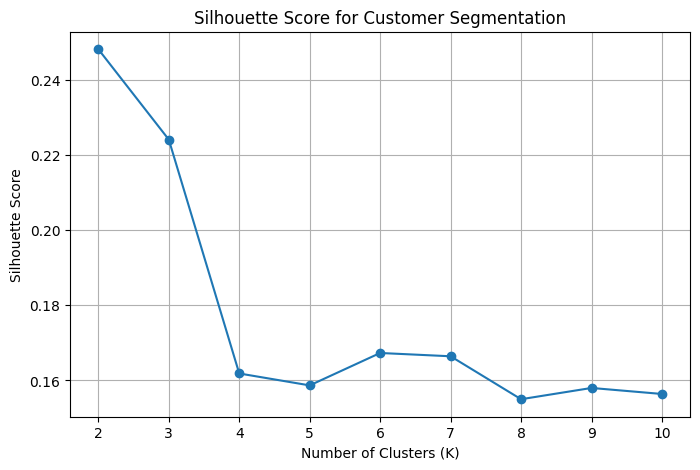

,k,silhouette_score
0,2,0.2481
1,3,0.2240
2,4,0.1619
3,5,0.1587
4,6,0.1673
5,7,0.1664
6,8,0.1550
7,9,0.1580
8,10,0.1564


In [34]:
# Plot Silhouette Scores for different numbers of clusters

plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_results['k'],
    silhouette_results['silhouette_score'],
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Customer Segmentation')

plt.xticks(silhouette_results['k'])
plt.grid(True)

plt.show()

# Display silhouette scores

silhouette_results[
    ['k', 'silhouette_score']
].round(4)

In [31]:
# Create a table comparing K values and silhouette scores

silhouette_results = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertia_values,
    'silhouette_score': silhouette_values
})

silhouette_results

,k,inertia,silhouette_score
0,2,7733.440836,0.248056
1,3,6845.556135,0.224041
2,4,6194.236789,0.161859
3,5,5650.509335,0.158692
4,6,5223.057279,0.167307
5,7,4962.554449,0.166432
6,8,4749.336213,0.155016
7,9,4525.878005,0.158011
8,10,4358.359330,0.156410


In [32]:
# Identify the K with the highest silhouette score

best_k = silhouette_results.loc[
    silhouette_results['silhouette_score'].idxmax(),
    'k'
]

best_silhouette = silhouette_results.loc[
    silhouette_results['silhouette_score'].idxmax(),
    'silhouette_score'
]

print('Best K based on silhouette score:', best_k)
print('Best silhouette score:', round(best_silhouette, 4))

Best K based on silhouette score: 2
Best silhouette score: 0.2481


In [ ]:
# Set the final number of customer segments

optimal_k = 2

# Elbow Method
#      ↓
# No extremely obvious elbow
#      ↓
# Silhouette Score
#      ↓
# Highest score = 0.2481
#      ↓
# K = 2

# K=2 provided the best separation among the tested configurations, 
# although the relatively low silhouette score indicates considerable overlap between customer groups.

In [36]:
# Train the final K-Means model

kmeans_model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

customer_clusters = kmeans_model.fit_predict(
    customer_scaled
)

In [37]:
# Add the cluster assignment to each customer

customer_features['customer_cluster'] = customer_clusters

In [38]:
# Check the number of customers in each cluster

customer_features['customer_cluster'].value_counts().sort_index()

customer_cluster
0    612
1    885
Name: count, dtype: int64

In [39]:
# Check the number of customers in each cluster

customer_features['customer_cluster'].value_counts().sort_index()

customer_cluster
0    612
1    885
Name: count, dtype: int64

In [40]:
# Calculate the percentage of customers in each cluster

cluster_distribution = (
    customer_features['customer_cluster']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_distribution

customer_cluster
0    40.88
1    59.12
Name: proportion, dtype: float64

In [41]:
# Check the number of customers in the feature dataset

print('Customer feature rows:', len(customer_features))
print('Original customers:', len(customers))

Customer feature rows: 1497
Original customers: 1500


In [42]:
# Check which customers are missing from the feature dataset

missing_customers = customers[
    ~customers['customer_id'].isin(
        customer_features['customer_id']
    )
]

missing_customers

,customer_id,age,gender,city,signup_date,membership_type
940,CUST_00941,35,Female,Kolkata,2025-01-04,Basic
1314,CUST_01315,28,Male,Chennai,2025-01-30,Basic
1371,CUST_01372,32,Female,Bengaluru,2025-01-18,Basic


In [44]:
# Preserve the original customer list
# so that every customer is included in the segmentation dataset

all_customers = customers[['customer_id']].copy()


# Remove the cluster column if it already exists
# because we are going to retrain K-Means

customer_features_base = customer_features.drop(
    columns='customer_cluster',
    errors='ignore'
)


# Merge the engineered features onto the complete customer list

customer_features = all_customers.merge(
    customer_features_base,
    on='customer_id',
    how='left'
)

# Check the number of customers

print('Customer feature rows:', len(customer_features))
print('Original customers:', len(customers))

Customer feature rows: 1500
Original customers: 1500


In [46]:
# Features representing customer activity should be zero
# when the customer has no recorded activity

zero_fill_columns = [
    'total_orders',
    'average_order_value',
    'total_spending',
    'ordering_frequency',
    'weekend_orders',
    'late_night_orders'
]

customer_features[zero_fill_columns] = (
    customer_features[zero_fill_columns]
    .fillna(0)
)


# Customers without a review have no rating.
# Impute their rating using the overall average rating.

customer_features['average_rating_given'] = (
    customer_features['average_rating_given']
    .fillna(
        customer_features['average_rating_given'].mean()
    )
)

# Verify that no missing values remain

customer_features.isna().sum()

customer_id             0
total_orders            0
average_order_value     0
total_spending          0
ordering_frequency      0
average_rating_given    0
weekend_orders          0
late_night_orders       0
dtype: int64

In [51]:
# Remove the customer identifier before model training

customer_model_data = customer_features.drop(
    columns='customer_id'
)

print('Model rows:', len(customer_model_data))
print('Model columns:', customer_model_data.shape[1])

Model rows: 1500
Model columns: 7


In [52]:
# Standardize the customer features

scaler = StandardScaler()

customer_scaled = scaler.fit_transform(
    customer_model_data
)

print('Scaled rows:', customer_scaled.shape[0])

Scaled rows: 1500


In [53]:
# Train the final K-Means model with 2 clusters

optimal_k = 2

kmeans_model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

customer_clusters = kmeans_model.fit_predict(
    customer_scaled
)

print('Cluster assignments:', len(customer_clusters))

Cluster assignments: 1500


In [54]:
# Add the cluster assignment to each customer

customer_features['customer_cluster'] = customer_clusters

In [ ]:
# Check cluster distribution

customer_features['customer_cluster'].value_counts().sort_index()

customer_cluster
0    888
1    612
Name: count, dtype: int64

In [56]:
# Create average feature values for each customer cluster

cluster_profile = (
    customer_features
    .groupby('customer_cluster')
    .agg({
        'total_orders': 'mean',
        'average_order_value': 'mean',
        'total_spending': 'mean',
        'ordering_frequency': 'mean',
        'average_rating_given': 'mean',
        'weekend_orders': 'mean',
        'late_night_orders': 'mean'
    })
    .round(2)
)

cluster_profile

,total_orders,average_order_value,total_spending,ordering_frequency,average_rating_given,weekend_orders,late_night_orders
customer_cluster,,,,,,,
0,5.01,661.01,3194.71,1.48,4.05,1.28,0.54
1,9.08,855.24,7538.22,2.14,4.05,2.83,1.33


In [57]:
# Calculate the percentage of customers in each cluster

cluster_size = (
    customer_features['customer_cluster']
    .value_counts()
    .sort_index()
)

cluster_percentage = (
    cluster_size / len(customer_features) * 100
).round(2)

cluster_percentage

customer_cluster
0    59.2
1    40.8
Name: count, dtype: float64

In [59]:
# Create a DataFrame containing the standardized features

profile_scaled = pd.DataFrame(
    customer_scaled,
    columns=customer_model_data.columns
)

profile_scaled['customer_cluster'] = (
    customer_features['customer_cluster'].values
)

# Calculate standardized feature averages by cluster

scaled_cluster_profile = (
    profile_scaled
    .groupby('customer_cluster')
    .mean()
)

scaled_cluster_profile.round(2)

,total_orders,average_order_value,total_spending,ordering_frequency,average_rating_given,weekend_orders,late_night_orders
customer_cluster,,,,,,,
0,-0.60,-0.21,-0.57,-0.47,0.00,-0.45,-0.34
1,0.87,0.31,0.82,0.68,-0.01,0.65,0.50


In [60]:
# Calculate standardized feature averages by cluster

scaled_cluster_profile = (
    profile_scaled
    .groupby('customer_cluster')
    .mean()
)

scaled_cluster_profile.round(2)

,total_orders,average_order_value,total_spending,ordering_frequency,average_rating_given,weekend_orders,late_night_orders
customer_cluster,,,,,,,
0,-0.60,-0.21,-0.57,-0.47,0.00,-0.45,-0.34
1,0.87,0.31,0.82,0.68,-0.01,0.65,0.50


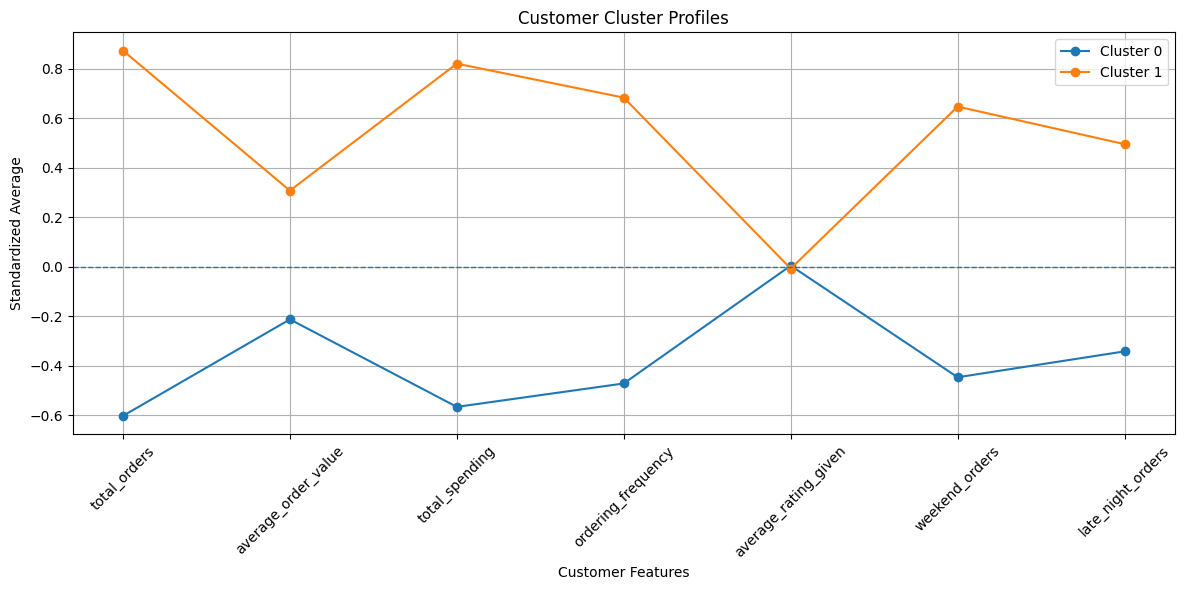

In [ ]:
# Plot standardized customer cluster profiles

plt.figure(figsize=(12, 6))

for cluster in scaled_cluster_profile.index:
    plt.plot(
        scaled_cluster_profile.columns,
        scaled_cluster_profile.loc[cluster],
        marker='o',
        label=f'Cluster {cluster}'
    )

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Customer Features')
plt.ylabel('Standardized Average')
plt.title('Customer Cluster Profiles')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Because these are standardized values 0 is overall mean.
# If its above average then its positive and vice versa. 

# Cluster 0 — Occasional Lower-Value Customers
# Cluster 1 — High-Value Frequent Customers

In [63]:
# Assign business-friendly names to the customer clusters

cluster_names = {
    0: 'Occasional Lower-Value Customers',
    1: 'High-Value Frequent Customers'
}

customer_features['customer_segment'] = (
    customer_features['customer_cluster']
    .map(cluster_names)
)

# View customer segment distribution

customer_features[
    'customer_segment'
].value_counts()

customer_segment
Occasional Lower-Value Customers    888
High-Value Frequent Customers       612
Name: count, dtype: int64

In [64]:
# Create a final customer segment profile

customer_segment_profile = (
    customer_features
    .groupby('customer_segment')
    .agg(
        customers=('customer_id', 'count'),
        avg_orders=('total_orders', 'mean'),
        avg_order_value=('average_order_value', 'mean'),
        avg_total_spending=('total_spending', 'mean'),
        avg_ordering_frequency=('ordering_frequency', 'mean'),
        avg_rating_given=('average_rating_given', 'mean'),
        avg_weekend_orders=('weekend_orders', 'mean'),
        avg_late_night_orders=('late_night_orders', 'mean')
    )
    .round(2)
)

customer_segment_profile

,customers,avg_orders,avg_order_value,avg_total_spending,avg_ordering_frequency,avg_rating_given,avg_weekend_orders,avg_late_night_orders
customer_segment,,,,,,,,
High-Value Frequent Customers,612,9.08,855.24,7538.22,2.14,4.05,2.83,1.33
Occasional Lower-Value Customers,888,5.01,661.01,3194.71,1.48,4.05,1.28,0.54


Cluster 0 – Occasional Lower-Value Customers: Customers with below-average ordering activity, spending, ordering frequency, weekend orders, and late-night orders. This segment represents customers with relatively low engagement and may benefit from targeted offers and re-engagement campaigns.

Cluster 1 – High-Value Frequent Customers: Customers with above-average ordering activity, spending, ordering frequency, weekend orders, and late-night orders. This represents the more engaged and valuable customer segment and could be targeted with loyalty programs, personalized recommendations, and retention strategies.

The silhouette score of 0.248 indicates that the two segments are only moderately separated, so these segments should be treated as useful behavioral groupings rather than completely distinct customer populations.

In [65]:
# Import DBSCAN clustering algorithm

from sklearn.cluster import DBSCAN

In [69]:
# Set the minimum number of samples used to define a dense region

min_samples = 5

# Calculate distances to the kth nearest neighbor

from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(customer_scaled)

distances, indices = neighbors.kneighbors(
    customer_scaled
)

# Extract the distance to the kth nearest neighbor

k_distances = distances[:, -1]

# Sort distances for the k-distance plot

k_distances = np.sort(k_distances)

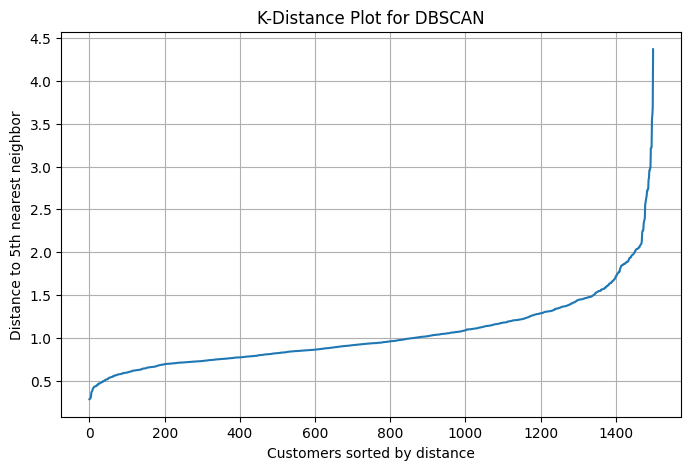

In [72]:
# Plot the k-distance curve to help select eps

plt.figure(figsize=(8, 5))

plt.plot(k_distances)

plt.xlabel('Customers sorted by distance')
plt.ylabel('Distance to 5th nearest neighbor')
plt.title('K-Distance Plot for DBSCAN')

plt.grid(True)

plt.show()

In [73]:
# Most customers have 5th-nearest-neighbor distances roughly between 0.6 and 1.5. 
# Then the curve starts rising more noticeably around 1.6–1.8, followed by a very steep rise near the end.

eps = 1.8
min_samples = 5

In the DBSCAN (Density-Based Spatial Clustering of Applications with Noise) algorithm, eps (epsilon) defines the maximum radius of the neighborhood around any data point. It serves as a distance threshold: if the distance between two data points is less than or equal to eps, they are considered neighbors.

In [75]:
# Create the DBSCAN model

dbscan_model = DBSCAN(
    eps=eps,
    min_samples=min_samples
)

In [76]:
# Fit DBSCAN and generate cluster labels

dbscan_labels = dbscan_model.fit_predict(
    customer_scaled
)

In [77]:
# Add DBSCAN cluster assignments to the customer dataset

customer_features['dbscan_cluster'] = dbscan_labels

In [78]:
# Count customers in each DBSCAN cluster

dbscan_distribution = (
    customer_features['dbscan_cluster']
    .value_counts()
    .sort_index()
)

dbscan_distribution

dbscan_cluster
-1      49
 0    1451
Name: count, dtype: int64

In [79]:
# Calculate the percentage of customers in each DBSCAN group

dbscan_percentage = (
    customer_features['dbscan_cluster']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

dbscan_percentage

dbscan_cluster
-1     3.27
 0    96.73
Name: proportion, dtype: float64

In [80]:
# Count the number of DBSCAN clusters, excluding noise

n_dbscan_clusters = (
    customer_features.loc[
        customer_features['dbscan_cluster'] != -1,
        'dbscan_cluster'
    ]
    .nunique()
)

# Count noise points

n_noise = (
    customer_features['dbscan_cluster'] == -1
).sum()

# Calculate noise percentage

noise_percentage = (
    n_noise / len(customer_features) * 100
)

print('Number of DBSCAN clusters:', n_dbscan_clusters)
print('Number of noise points:', n_noise)
print('Noise percentage:', round(noise_percentage, 2), '%')

Number of DBSCAN clusters: 1
Number of noise points: 49
Noise percentage: 3.27 %


In [81]:
# For segmentation, one cluster isn't very useful because '
# 'DBSCAN hasn't actually separated your customers into different behavioral groups.

# This means eps = 1.8 is probably too large for your data.

In [82]:
# Try with smaller eps

dbscan_model = DBSCAN(
    eps=1.4,
    min_samples=5
)

dbscan_labels = dbscan_model.fit_predict(
    customer_scaled
)

customer_features['dbscan_cluster'] = dbscan_labels

In [83]:
# Count DBSCAN clusters, excluding noise

n_dbscan_clusters = (
    customer_features.loc[
        customer_features['dbscan_cluster'] != -1,
        'dbscan_cluster'
    ]
    .nunique()
)

# Count noise points

n_noise = (
    customer_features['dbscan_cluster'] == -1
).sum()

# Calculate noise percentage

noise_percentage = (
    n_noise / len(customer_features) * 100
)

print('Number of DBSCAN clusters:', n_dbscan_clusters)
print('Number of noise points:', n_noise)
print(
    'Noise percentage:',
    round(noise_percentage, 2),
    '%'
)

Number of DBSCAN clusters: 1
Number of noise points: 122
Noise percentage: 8.13 %


In [84]:
# Show the distribution of DBSCAN clusters

customer_features[
    'dbscan_cluster'
].value_counts().sort_index()

dbscan_cluster
-1     122
 0    1378
Name: count, dtype: int64

In [85]:
# Run DBSCAN with a smaller eps value

dbscan_model = DBSCAN(
    eps=1.0,
    min_samples=5
)

dbscan_labels = dbscan_model.fit_predict(
    customer_scaled
)

customer_features['dbscan_cluster'] = dbscan_labels

In [86]:
# Count DBSCAN clusters, excluding noise

n_dbscan_clusters = (
    customer_features.loc[
        customer_features['dbscan_cluster'] != -1,
        'dbscan_cluster'
    ]
    .nunique()
)

# Count noise points

n_noise = (
    customer_features['dbscan_cluster'] == -1
).sum()

# Calculate noise percentage

noise_percentage = (
    n_noise / len(customer_features) * 100
)

print('Number of DBSCAN clusters:', n_dbscan_clusters)
print('Number of noise points:', n_noise)
print(
    'Noise percentage:',
    round(noise_percentage, 2),
    '%'
)

# Show cluster distribution

customer_features[
    'dbscan_cluster'
].value_counts().sort_index()

Number of DBSCAN clusters: 9
Number of noise points: 412
Noise percentage: 27.47 %


dbscan_cluster
-1    412
 0    129
 1    497
 2    426
 3      7
 4      6
 5     11
 6      4
 7      4
 8      4
Name: count, dtype: int64

There are more clusters but sizes of these clusters are very small
We need a higher eps than 1.0


In [87]:
# Run DBSCAN with an intermediate eps value

dbscan_model = DBSCAN(
    eps=1.2,
    min_samples=5
)

dbscan_labels = dbscan_model.fit_predict(
    customer_scaled
)

customer_features['dbscan_cluster'] = dbscan_labels

In [88]:
# Count DBSCAN clusters, excluding noise

n_dbscan_clusters = (
    customer_features.loc[
        customer_features['dbscan_cluster'] != -1,
        'dbscan_cluster'
    ]
    .nunique()
)

# Count noise points

n_noise = (
    customer_features['dbscan_cluster'] == -1
).sum()

# Calculate noise percentage

noise_percentage = (
    n_noise / len(customer_features) * 100
)

print('Number of DBSCAN clusters:', n_dbscan_clusters)
print('Number of noise points:', n_noise)
print(
    'Noise percentage:',
    round(noise_percentage, 2),
    '%'
)

# Display cluster distribution

customer_features[
    'dbscan_cluster'
].value_counts().sort_index()

Number of DBSCAN clusters: 1
Number of noise points: 241
Noise percentage: 16.07 %


dbscan_cluster
-1     241
 0    1259
Name: count, dtype: int64

In [89]:
# Run DBSCAN with a final intermediate eps value

dbscan_model = DBSCAN(
    eps=1.1,
    min_samples=5
)

dbscan_labels = dbscan_model.fit_predict(
    customer_scaled
)

customer_features['dbscan_cluster'] = dbscan_labels

In [90]:
# Count DBSCAN clusters, excluding noise

n_dbscan_clusters = (
    customer_features.loc[
        customer_features['dbscan_cluster'] != -1,
        'dbscan_cluster'
    ]
    .nunique()
)

# Count noise points

n_noise = (
    customer_features['dbscan_cluster'] == -1
).sum()

# Calculate noise percentage

noise_percentage = (
    n_noise / len(customer_features) * 100
)

print('Number of DBSCAN clusters:', n_dbscan_clusters)
print('Number of noise points:', n_noise)
print(
    'Noise percentage:',
    round(noise_percentage, 2),
    '%'
)

# Display cluster distribution

print(
    customer_features[
        'dbscan_cluster'
    ].value_counts().sort_index()
)

Number of DBSCAN clusters: 3
Number of noise points: 310
Noise percentage: 20.67 %
dbscan_cluster
-1     310
 0    1181
 1       6
 2       3
Name: count, dtype: int64


DBSCAN is showing that your synthetic customer data doesn't have a particularly strong density-based structure. That's perfectly valid.

DBSCAN was evaluated using multiple eps values. At higher eps values, DBSCAN grouped almost all customers into a single cluster. At lower values, the algorithm classified a substantial proportion of customers as noise and produced several very small clusters. Therefore, DBSCAN did not identify a meaningful density-based customer segmentation for this dataset. K-Means was selected as the primary segmentation method.

In [92]:
# Import PCA

from sklearn.decomposition import PCA

In [93]:
# Create PCA with two components for visualization

pca = PCA(n_components=2)

# Transform the scaled customer features into two dimensions

customer_pca_values = pca.fit_transform(
    customer_scaled
)

In [94]:
# Store the PCA components in a DataFrame

customer_pca = pd.DataFrame(
    customer_pca_values,
    columns=['PC1', 'PC2'],
    index=customer_features.index
)

customer_pca.head()

,PC1,PC2
0,-0.106971,-0.122342
1,2.309149,0.243192
2,-1.728722,0.360139
3,-1.111486,-0.062351
4,-0.446468,0.123515


In [95]:
# Display the variance explained by each principal component

print(
    'Explained variance ratio:',
    pca.explained_variance_ratio_
)

print(
    'Total variance explained:',
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio: [0.39908932 0.18569703]
Total variance explained: 0.5847863520334622


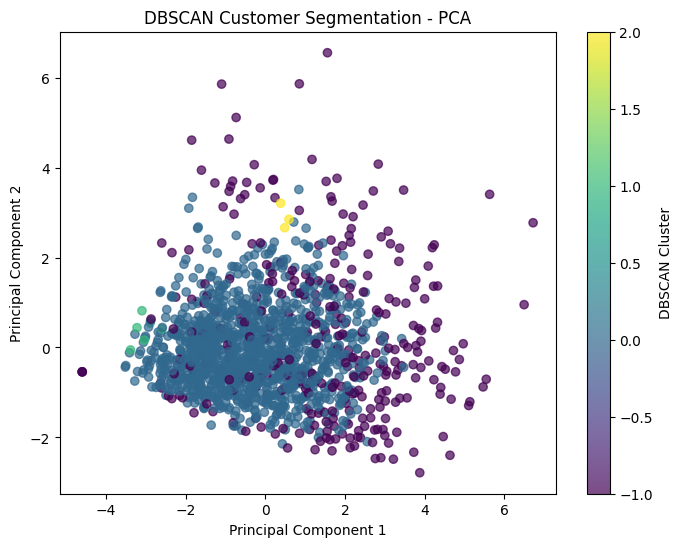

In [96]:
# Visualize DBSCAN clusters using the first two PCA components

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    customer_pca['PC1'],
    customer_pca['PC2'],
    c=customer_features['dbscan_cluster'],
    alpha=0.7
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Customer Segmentation - PCA')

plt.colorbar(
    scatter,
    label='DBSCAN Cluster'
)

plt.show()

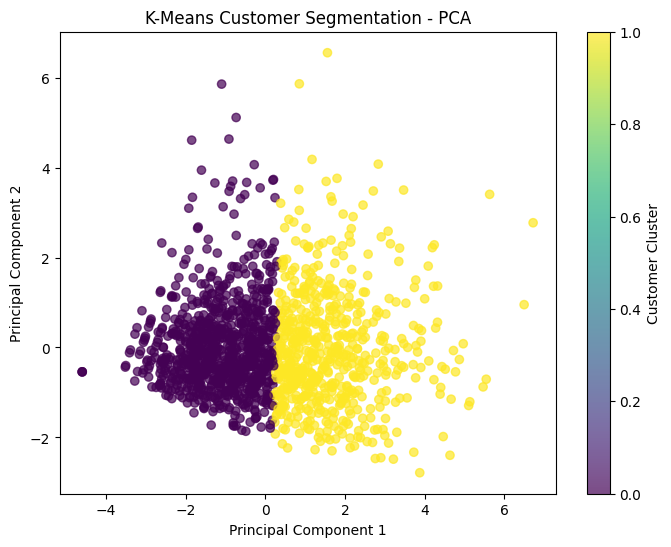

In [104]:
# Plot K-Means customer clusters using PCA components

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    customer_pca['PC1'],
    customer_pca['PC2'],
    c=customer_features['customer_cluster'],
    alpha=0.7
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Customer Segmentation - PCA')

plt.colorbar(
    scatter,
    label='Customer Cluster'
)

plt.show()

In [97]:
# Calculate customer count and percentage for each K-Means cluster

cluster_distribution = (
    customer_features['customer_cluster']
    .value_counts()
    .sort_index()
    .to_frame('customer_count')
)

cluster_distribution['percentage'] = (
    cluster_distribution['customer_count']
    / len(customer_features)
    * 100
).round(2)

cluster_distribution

,customer_count,percentage
customer_cluster,,
0,888,59.2
1,612,40.8


In [99]:
# Define the features used for customer segmentation

customer_profile_features = [
    'total_orders',
    'average_order_value',
    'total_spending',
    'ordering_frequency',
    'average_rating_given',
    'weekend_orders',
    'late_night_orders'
]
# Calculate the average customer behavior for each K-Means cluster

cluster_profiles = (
    customer_features
    .groupby('customer_cluster')[customer_profile_features]
    .mean()
    .round(2)
)

cluster_profiles

,total_orders,average_order_value,total_spending,ordering_frequency,average_rating_given,weekend_orders,late_night_orders
customer_cluster,,,,,,,
0,5.01,661.01,3194.71,1.48,4.05,1.28,0.54
1,9.08,855.24,7538.22,2.14,4.05,2.83,1.33


In [100]:
# Map K-Means cluster numbers to business-friendly names

cluster_names = {
    0: 'Occasional Moderate-Value Customers',
    1: 'Frequent High-Value Customers'
}

cluster_profiles_named = cluster_profiles.copy()

cluster_profiles_named.index = (
    cluster_profiles_named.index
    .map(cluster_names)
)

cluster_profiles_named

,total_orders,average_order_value,total_spending,ordering_frequency,average_rating_given,weekend_orders,late_night_orders
customer_cluster,,,,,,,
Occasional Moderate-Value Customers,5.01,661.01,3194.71,1.48,4.05,1.28,0.54
Frequent High-Value Customers,9.08,855.24,7538.22,2.14,4.05,2.83,1.33


In [101]:
# Add business-friendly cluster names to the customer dataset

customer_features['customer_segment'] = (
    customer_features['customer_cluster']
    .map(cluster_names)
)

customer_features[
    ['customer_cluster', 'customer_segment']
].head()

,customer_cluster,customer_segment
0,0,Occasional Moderate-Value Customers
1,1,Frequent High-Value Customers
2,0,Occasional Moderate-Value Customers
3,0,Occasional Moderate-Value Customers
4,0,Occasional Moderate-Value Customers


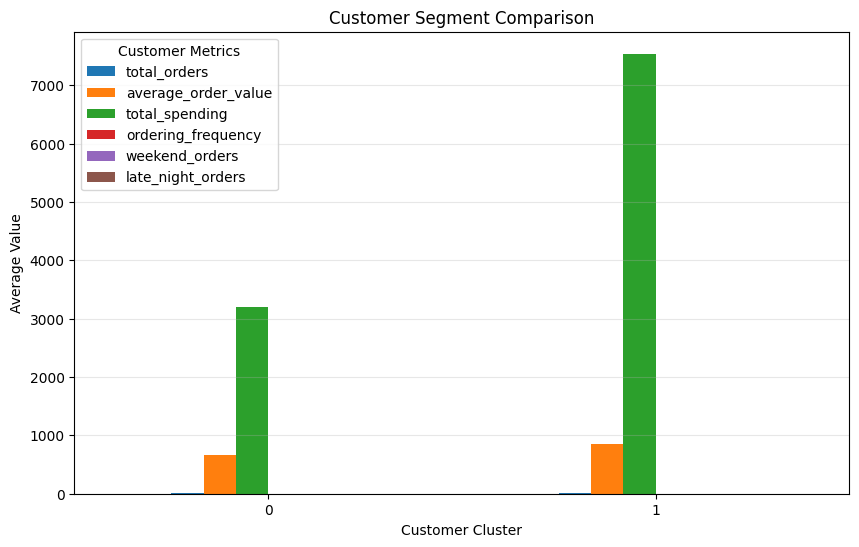

In [102]:
# Compare key customer metrics across K-Means clusters

cluster_plot_data = cluster_profiles[
    [
        'total_orders',
        'average_order_value',
        'total_spending',
        'ordering_frequency',
        'weekend_orders',
        'late_night_orders'
    ]
]

cluster_plot_data.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel('Customer Cluster')
plt.ylabel('Average Value')
plt.title('Customer Segment Comparison')
plt.xticks(rotation=0)
plt.legend(title='Customer Metrics')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [105]:
# Save the final customer segmentation dataset

customer_features.to_csv(
    '../data/processed/customer_segmentation.csv',
    index=False
)

print('Customer segmentation dataset saved successfully.')

Customer segmentation dataset saved successfully.
